In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

print('Libraries imported successfully')

Libraries imported successfully


In [2]:
# Load dataset
df = pd.read_csv('cleaned_sales_data.csv')

# Display first 5 rows
df.head()

,Order_ID,Order_Date,Order_Year,Order_Month,Order_Quarter,Order_Weekday,Customer_ID,Customer_Name,Age,Age_Group,...,City,Product,Category,Quantity,Unit_Price,Total_Sales,Is_Sales_Outlier,Age_Imputed,City_Imputed,Is_Duplicate_ID_Fixed
0,ORD100002,2025-02-25,2025,February,1,Tuesday,CUST5529,Customer_227,30,26-35,...,Bengaluru,Rice,Grocery,7,2829.77,19808.39,False,False,False,False
1,ORD100003,2025-10-14,2025,October,4,Tuesday,CUST3127,Customer_182,63,56-65,...,Bengaluru,Book,Education,5,27906.16,139530.80,False,False,False,False
2,ORD100004,2025-05-13,2025,May,2,Tuesday,CUST8887,Customer_487,62,56-65,...,Bengaluru,Book,Education,8,37491.06,299928.48,False,False,False,False
3,ORD100005,2025-12-02,2025,December,4,Tuesday,CUST2515,Customer_470,65,56-65,...,Kolkata,Mobile,Electronics,9,28541.36,256872.24,False,False,False,False
4,ORD100006,2025-11-20,2025,November,4,Thursday,CUST4796,Customer_380,44,36-45,...,Bengaluru,Rice,Grocery,10,14036.59,140365.90,False,False,False,False


In [3]:
# Shape
print('Shape:', df.shape)

# Column names
print('\nColumns:')
print(df.columns)

# Dataset info
print('\nDataset Info:')
df.info()

Shape: (1000, 21)

Columns:
Index(['Order_ID', 'Order_Date', 'Order_Year', 'Order_Month', 'Order_Quarter',
       'Order_Weekday', 'Customer_ID', 'Customer_Name', 'Age', 'Age_Group',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales', 'Is_Sales_Outlier', 'Age_Imputed', 'City_Imputed',
       'Is_Duplicate_ID_Fixed'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               1000 non-null   str    
 1   Order_Date             1000 non-null   str    
 2   Order_Year             1000 non-null   int64  
 3   Order_Month            1000 non-null   str    
 4   Order_Quarter          1000 non-null   int64  
 5   Order_Weekday          1000 non-null   str    
 6   Customer_ID            1000 non-null   str    
 7   Customer_Name          1000 non-nul

In [4]:
# Missing values
df.isnull().sum()

Order_ID                 0
Order_Date               0
Order_Year               0
Order_Month              0
Order_Quarter            0
Order_Weekday            0
Customer_ID              0
Customer_Name            0
Age                      0
Age_Group                0
Gender                   0
City                     0
Product                  0
Category                 0
Quantity                 0
Unit_Price               0
Total_Sales              0
Is_Sales_Outlier         0
Age_Imputed              0
City_Imputed             0
Is_Duplicate_ID_Fixed    0
dtype: int64

In [5]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

In [6]:
# Numerical summary
df.describe()

,Order_Year,Order_Quarter,Age,Quantity,Unit_Price,Total_Sales
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025.005000,2.499000,41.353000,5.435000,25486.783410,139399.439650
std,0.070569,1.131937,13.683626,2.838632,14179.402361,114100.051546
min,2025.000000,1.000000,18.000000,1.000000,145.780000,437.340000
25%,2025.000000,1.000000,30.000000,3.000000,13895.722500,47066.632500
50%,2025.000000,2.000000,41.000000,5.000000,25398.740000,108594.025000
75%,2025.000000,4.000000,53.000000,8.000000,37512.382500,203722.882500
max,2026.000000,4.000000,65.000000,10.000000,49997.530000,493677.500000


In [7]:
# Categorical summary
df.describe(include=['object', 'str'])

,Order_ID,Order_Date,Order_Month,Order_Weekday,Customer_ID,Customer_Name,Age_Group,Gender,City,Product,Category
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,342,12,7,947,425,5,2,9,6,5
top,ORD100002,2025-04-16,December,Sunday,CUST2515,Customer_359,36-45,Male,Patna,Mobile,Electronics
freq,1,10,98,153,3,8,223,511,135,184,354


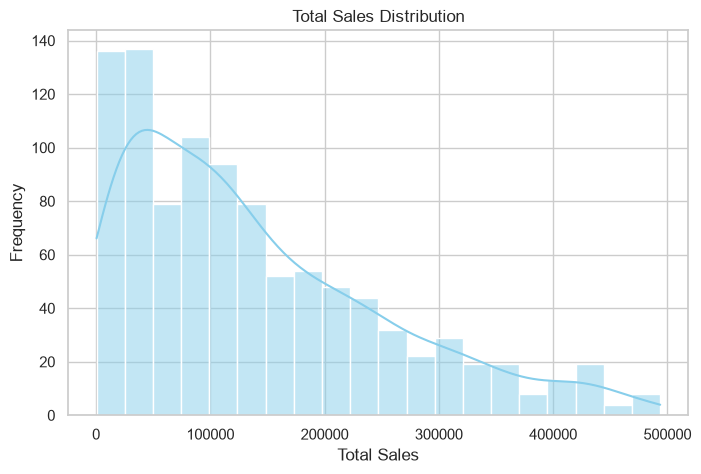

In [8]:
sales_col = 'Total_Sales'

plt.figure(figsize=(8,5))
sns.histplot(df[sales_col], bins=20, kde=True, color='skyblue')
plt.title('Total Sales Distribution')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.show()

C:\Users\Ancha\AppData\Local\Temp\ipykernel_360\3866789424.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.index, y=top_products.values, palette='viridis')


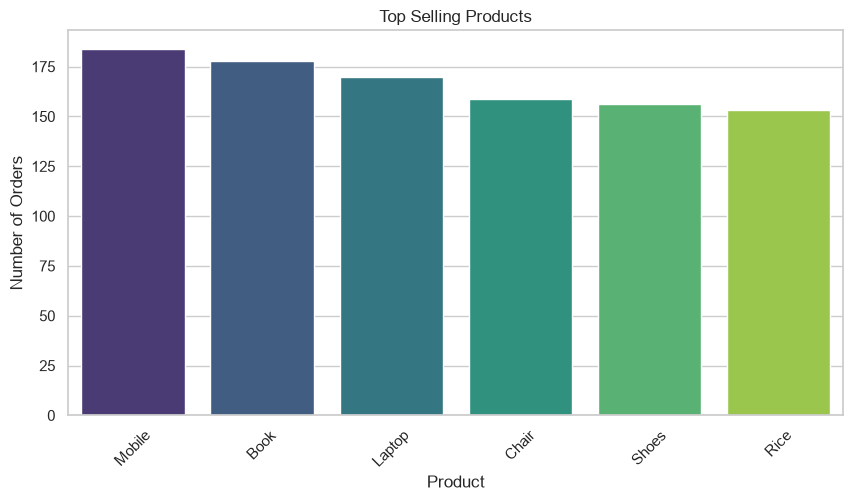

In [9]:
top_products = df['Product'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.index, y=top_products.values, palette='viridis')
plt.title('Top Selling Products')
plt.xlabel('Product')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

C:\Users\Ancha\AppData\Local\Temp\ipykernel_360\4127255552.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='magma')


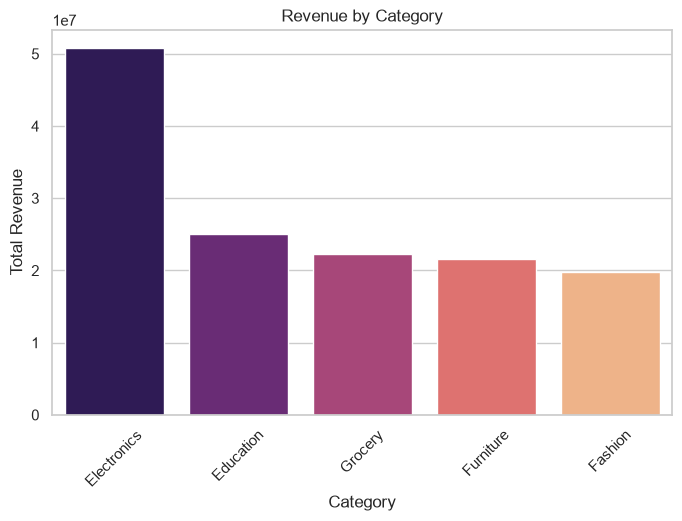

In [10]:
category_sales = df.groupby('Category')[sales_col].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='magma')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

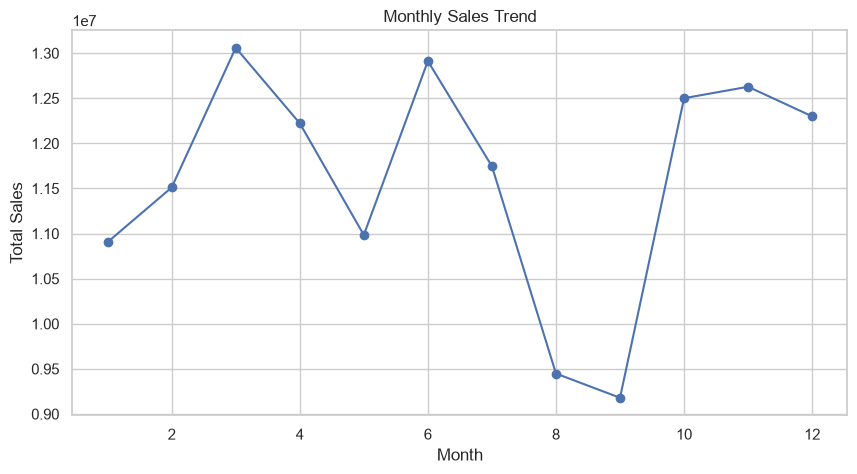

In [11]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

monthly_sales = df.groupby(df['Order_Date'].dt.month)[sales_col].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

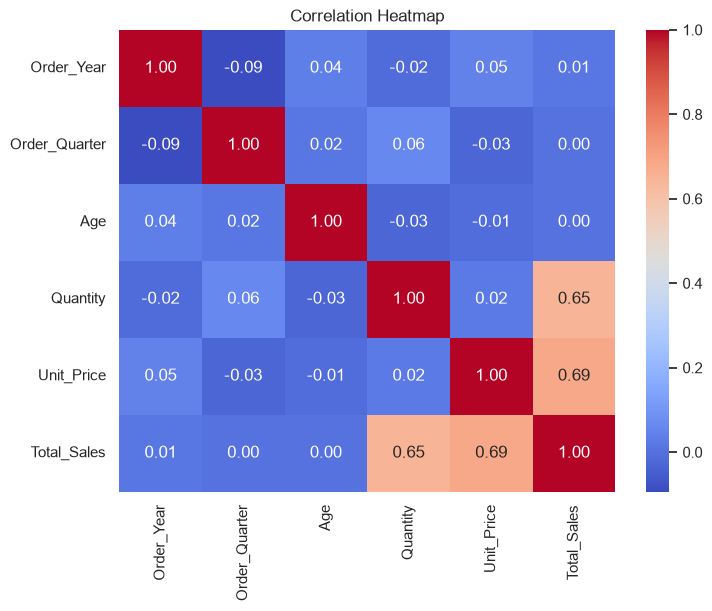

In [12]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

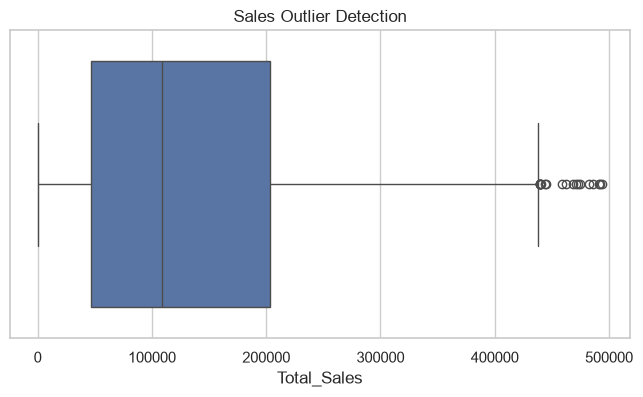

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df[sales_col])
plt.title('Sales Outlier Detection')
plt.show()

In [14]:
print('===== BUSINESS INSIGHTS =====')
print(f'Total Records: {len(df)}')
print(f'Total Revenue: ₹{df[sales_col].sum():,.2f}')
print(f'Average Order Value: ₹{df[sales_col].mean():,.2f}')
print(f'Most Frequently Sold Product: {df["Product"].value_counts().idxmax()}')
print(f'Highest Revenue Category: {df.groupby("Category")[sales_col].sum().idxmax()}')
print(f'Highest Revenue City: {df.groupby("City")[sales_col].sum().idxmax()}')

===== BUSINESS INSIGHTS =====
Total Records: 1000
Total Revenue: ₹139,399,439.65
Average Order Value: ₹139,399.44
Most Frequently Sold Product: Mobile
Highest Revenue Category: Electronics
Highest Revenue City: Patna


In [15]:
with open('eda_summary_report.txt', 'w') as f:
    f.write('EDA SUMMARY REPORT\n')
    f.write('='*40 + '\n\n')
    f.write(f'Total Records: {len(df)}\n')
    f.write(f'Total Revenue: {df[sales_col].sum():,.2f}\n')
    f.write(f'Average Order Value: {df[sales_col].mean():,.2f}\n')
    f.write(f'Duplicate Rows: {df.duplicated().sum()}\n')

print('EDA report saved successfully.')

EDA report saved successfully.


In [1]:
import sqlite3
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("../Task2-EDA-BI/cleaned_sales_data.csv")

# Create SQLite database
connection = sqlite3.connect("task2_sales.db")

# Create sales table
df.to_sql("sales", connection, if_exists="replace", index=False)

print("Sales table created successfully!")

Sales table created successfully!


In [2]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    connection
)

tables

,name
0,sales


In [3]:
query = """
SELECT
    Product,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales
GROUP BY Product
ORDER BY Total_Revenue DESC
LIMIT 5;
"""

result = pd.read_sql_query(query, connection)

result

,Product,Total_Revenue
0,Laptop,25443008.51
1,Mobile,25335573.19
2,Book,25031689.40
3,Rice,22231711.28
4,Chair,21521561.48


In [4]:
query_2 = """
SELECT
    Category,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales
GROUP BY Category
ORDER BY Total_Revenue DESC;
"""

result_2 = pd.read_sql_query(query_2, connection)

result_2

,Category,Total_Revenue
0,Electronics,50778581.70
1,Education,25031689.40
2,Grocery,22231711.28
3,Furniture,21521561.48
4,Fashion,19835895.79


In [5]:
query_3 = """
SELECT
    Order_Year,
    Order_Month,
    ROUND(SUM(Total_Sales), 2) AS Monthly_Sales
FROM sales
GROUP BY Order_Year, Order_Month
ORDER BY Order_Year, Order_Month;
"""

result_3 = pd.read_sql_query(query_3, connection)

result_3

,Order_Year,Order_Month,Monthly_Sales
0,2025,April,12222700.17
1,2025,August,9448471.22
2,2025,December,12299904.44
3,2025,February,11511181.46
4,2025,January,10096190.73
5,2025,July,11746226.80
6,2025,June,12912332.64
7,2025,March,13059899.94
8,2025,May,10984689.25
9,2025,November,12627620.22


In [6]:
query_4 = """
SELECT
    City,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales
GROUP BY City
ORDER BY Total_Revenue DESC
LIMIT 5;
"""

result_4 = pd.read_sql_query(query_4, connection)

result_4

,City,Total_Revenue
0,Patna,19285966.89
1,Kolkata,18884349.57
2,Bengaluru,18773574.32
3,Mumbai,18757050.17
4,Hyderabad,17166766.87


In [7]:
query_5 = """
SELECT
    Age_Group,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales
GROUP BY Age_Group
ORDER BY Total_Revenue DESC;
"""

result_5 = pd.read_sql_query(query_5, connection)

result_5

,Age_Group,Total_Revenue
0,36-45,31533245.71
1,26-35,29632336.96
2,46-55,28216508.63
3,56-65,27733251.41
4,18-25,22284096.94


In [8]:
query_6 = """
SELECT
    Gender,
    COUNT(*) AS Number_of_Orders,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales
GROUP BY Gender
ORDER BY Total_Revenue DESC;
"""

result_6 = pd.read_sql_query(query_6, connection)

result_6

,Gender,Number_of_Orders,Total_Revenue
0,Male,511,72463550.63
1,Female,489,66935889.02


In [9]:
query_7 = """
SELECT
    Customer_ID,
    Customer_Name,
    COUNT(Order_ID) AS Number_of_Orders,
    ROUND(SUM(Total_Sales), 2) AS Total_Revenue
FROM sales
GROUP BY Customer_ID, Customer_Name
ORDER BY Total_Revenue DESC
LIMIT 10;
"""

result_7 = pd.read_sql_query(query_7, connection)

result_7

,Customer_ID,Customer_Name,Number_of_Orders,Total_Revenue
0,CUST2062,Customer_254,1,493677.5
1,CUST4706,Customer_200,1,492174.1
2,CUST1711,Customer_36,1,490866.4
3,CUST4869,Customer_392,1,485667.8
4,CUST7416,Customer_191,1,482551.9
5,CUST9551,Customer_230,1,474935.9
6,CUST8381,Customer_112,1,473144.2
7,CUST4037,Customer_205,1,470798.6
8,CUST4003,Customer_305,1,468522.0
9,CUST4584,Customer_138,1,462701.3


In [10]:
# Create a separate customer table

customer_columns = [
    'Customer_ID',
    'Customer_Name',
    'Age',
    'Age_Group',
    'Gender',
    'City'
]

customers = df[customer_columns].drop_duplicates(
    subset='Customer_ID'
)

customers.to_sql(
    'customers',
    connection,
    if_exists='replace',
    index=False
)

print("Customers table created successfully!")

Customers table created successfully!


In [11]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    connection
)

tables

,name
0,sales
1,customers


In [12]:
join_query = """
SELECT
    s.Customer_ID,
    c.Customer_Name,
    c.City,
    COUNT(s.Order_ID) AS Number_of_Orders,
    ROUND(SUM(s.Total_Sales), 2) AS Total_Revenue
FROM sales AS s
INNER JOIN customers AS c
    ON s.Customer_ID = c.Customer_ID
GROUP BY
    s.Customer_ID,
    c.Customer_Name,
    c.City
ORDER BY Total_Revenue DESC
LIMIT 10;
"""

join_result = pd.read_sql_query(
    join_query,
    connection
)

join_result

,Customer_ID,Customer_Name,City,Number_of_Orders,Total_Revenue
0,CUST9510,Customer_345,Kolkata,2,867333.24
1,CUST6845,Customer_337,Hyderabad,2,769479.75
2,CUST6532,Customer_348,Pune,2,610981.74
3,CUST6082,Customer_301,Mumbai,2,548416.39
4,CUST3689,Customer_179,Delhi,2,542484.08
5,CUST3730,Customer_273,Unknown,2,538633.97
6,CUST4706,Customer_34,Delhi,2,528036.44
7,CUST9693,Customer_343,Patna,2,511421.86
8,CUST7374,Customer_375,Patna,2,511309.40
9,CUST2062,Customer_254,Patna,1,493677.50


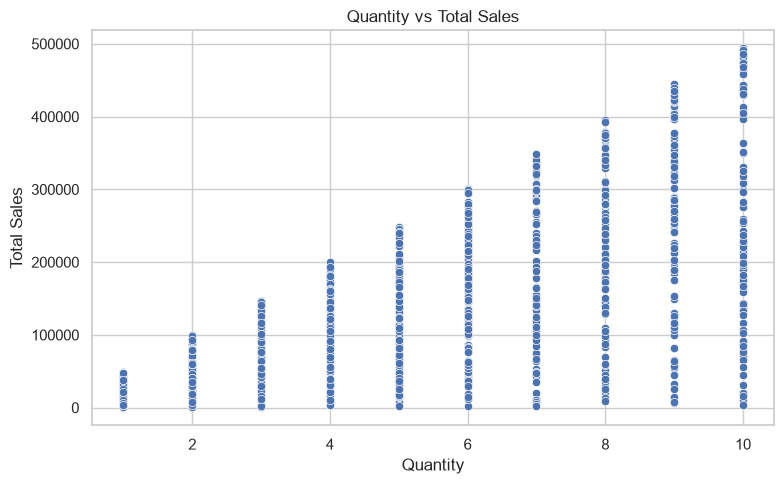

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='Total_Sales'
)

plt.title('Quantity vs Total Sales')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [17]:
print(df.shape)

(1000, 21)


In [19]:
df = pd.read_csv("cleaned_sales_data.csv")

print(df.head())

    Order_ID  Order_Date  Order_Year Order_Month  Order_Quarter Order_Weekday  \
0  ORD100002  2025-02-25        2025    February              1       Tuesday   
1  ORD100003  2025-10-14        2025     October              4       Tuesday   
2  ORD100004  2025-05-13        2025         May              2       Tuesday   
3  ORD100005  2025-12-02        2025    December              4       Tuesday   
4  ORD100006  2025-11-20        2025    November              4      Thursday   

  Customer_ID Customer_Name  Age Age_Group  ...       City Product  \
0    CUST5529  Customer_227   30     26-35  ...  Bengaluru    Rice   
1    CUST3127  Customer_182   63     56-65  ...  Bengaluru    Book   
2    CUST8887  Customer_487   62     56-65  ...  Bengaluru    Book   
3    CUST2515  Customer_470   65     56-65  ...    Kolkata  Mobile   
4    CUST4796  Customer_380   44     36-45  ...  Bengaluru    Rice   

      Category Quantity  Unit_Price  Total_Sales  Is_Sales_Outlier  \
0      Grocery        

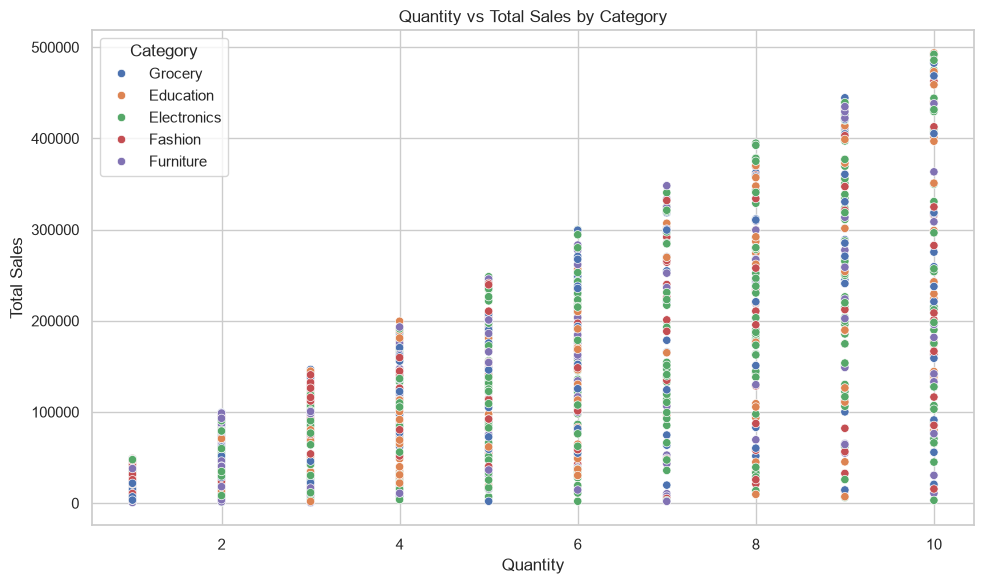

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='Total_Sales',
    hue='Category'
)

plt.title('Quantity vs Total Sales by Category')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

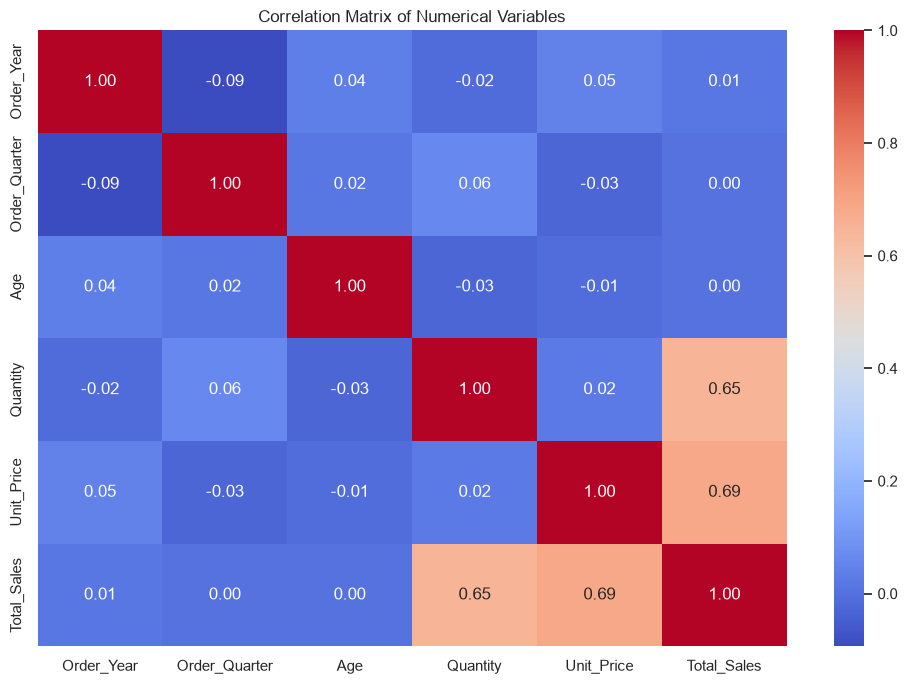

In [21]:
# Correlation Matrix

numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

In [22]:
corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

print("Strongest Correlations:")
print(corr_pairs.head(10))

Strongest Correlations:
Unit_Price     Total_Sales    0.686303
Quantity       Total_Sales    0.646641
Order_Quarter  Quantity       0.061040
Order_Year     Unit_Price     0.045437
               Age            0.035489
Quantity       Unit_Price     0.021855
Order_Quarter  Age            0.016600
Order_Year     Total_Sales    0.013972
Order_Quarter  Total_Sales    0.001508
Age            Total_Sales    0.001294
dtype: float64


In [24]:
# Dashboard KPI Summary

total_sales = df['Total_Sales'].sum()
total_orders = df['Order_ID'].nunique()
average_order_value = total_sales / total_orders

top_product = (
    df.groupby('Product')['Total_Sales']
    .sum()
    .idxmax()
)

top_category = (
    df.groupby('Category')['Total_Sales']
    .sum()
    .idxmax()
)

top_city = (
    df.groupby('City')['Total_Sales']
    .sum()
    .idxmax()
)

print("----- DASHBOARD KPIs -----")
print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))
print("Top Product:", top_product)
print("Top Category:", top_category)
print("Top City:", top_city)

----- DASHBOARD KPIs -----
Total Sales: 139399439.65
Total Orders: 1000
Average Order Value: 139399.44
Top Product: Laptop
Top Category: Electronics
Top City: Patna
